In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

con = duckdb.connect('../data/olist.duckdb')
con.execute("""
    CREATE OR REPLACE VIEW delivered AS
    SELECT * FROM read_parquet('../data/delivered_orders.parquet')
""")

print("✓ Connected")

✓ Connected


In [3]:
rfm = con.execute("""
    WITH

    -- Snapshot date = day after last order in dataset
    snapshot AS (
        SELECT MAX(purchased_at) + INTERVAL '1 day' AS ref_date
        FROM delivered
    ),

    -- Raw RFM metrics per customer
    rfm_raw AS (
        SELECT
            d.customer_id,
            d.customer_state,

            -- Recency: days since last purchase
            DATEDIFF('day',
                MAX(d.purchased_at),
                s.ref_date
            )                                           AS recency_days,

            -- Frequency: number of orders
            COUNT(DISTINCT d.order_id)                  AS frequency,

            -- Monetary: total spend
            ROUND(SUM(d.total_payment), 2)              AS monetary,

            -- Extra context
            ROUND(AVG(d.review_score), 2)               AS avg_review,
            ROUND(AVG(d.total_payment), 2)              AS avg_order_value,
            MIN(d.purchased_at)::DATE                   AS first_purchase,
            MAX(d.purchased_at)::DATE                   AS last_purchase

        FROM delivered d
        CROSS JOIN snapshot s
        GROUP BY d.customer_id, d.customer_state, s.ref_date
    ),

    -- Score each metric 1-4 using quartiles
    -- Recency: LOWER days = BETTER (score 4)
    -- Frequency & Monetary: HIGHER = BETTER (score 4)
    rfm_scored AS (
        SELECT
            *,
            NTILE(4) OVER (ORDER BY recency_days DESC)  AS r_score,
            NTILE(4) OVER (ORDER BY frequency    ASC)   AS f_score,
            NTILE(4) OVER (ORDER BY monetary     ASC)   AS m_score
        FROM rfm_raw
    ),

    -- Combine into RFM score string and total score
    rfm_combined AS (
        SELECT
            *,
            CONCAT(r_score, f_score, m_score)           AS rfm_string,
            r_score + f_score + m_score                 AS rfm_total
        FROM rfm_scored
    )

    SELECT * FROM rfm_combined
    ORDER BY rfm_total DESC

""").df()

con.register('rfm', rfm)

print(f"Customers scored: {len(rfm):,}")
print(rfm[['recency_days','frequency','monetary',
           'r_score','f_score','m_score','rfm_total']].describe().round(2))

Customers scored: 96,211
       recency_days  frequency  monetary   r_score   f_score   m_score  \
count      96211.00    96211.0  96211.00  96211.00  96211.00  96211.00   
mean         239.40        1.0    159.81      2.50      2.50      2.50   
std          151.19        0.0    218.88      1.12      1.12      1.12   
min            1.00        1.0      9.59      1.00      1.00      1.00   
25%          116.00        1.0     61.88      1.50      1.50      1.50   
50%          221.00        1.0    105.28      2.00      2.00      2.00   
75%          349.00        1.0    176.26      3.00      3.00      3.00   
max          602.00        1.0  13664.08      4.00      4.00      4.00   

       rfm_total  
count   96211.00  
mean        7.50  
std         2.45  
min         3.00  
25%         6.00  
50%         8.00  
75%         9.00  
max        12.00  


In [4]:
def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']
    t = row['rfm_total']

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r >= 3 and f == 1:
        return 'Promising'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 2 and f == 1:
        return 'Need Attention'
    elif r == 1 and f >= 2:
        return 'Cant Lose Them'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
con.register('rfm', rfm)

seg_counts = rfm['segment'].value_counts()
print("\nSEGMENT DISTRIBUTION:")
print(seg_counts)


SEGMENT DISTRIBUTION:
segment
Loyal        27110
At Risk      24053
Lost         24053
Champions    20995
Name: count, dtype: int64


In [5]:
seg_summary = con.execute("""
    SELECT
        segment,
        COUNT(*)                                        AS customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(),1) AS pct_customers,
        ROUND(AVG(recency_days), 0)                     AS avg_recency_days,
        ROUND(AVG(frequency), 2)                        AS avg_frequency,
        ROUND(AVG(monetary), 2)                         AS avg_monetary,
        ROUND(SUM(monetary), 0)                         AS total_revenue,
        ROUND(100.0 * SUM(monetary)
              / SUM(SUM(monetary)) OVER (), 1)          AS pct_revenue,
        ROUND(AVG(avg_review), 2)                       AS avg_review_score
    FROM rfm
    GROUP BY segment
    ORDER BY total_revenue DESC
""").df()

print("\nSEGMENT REVENUE BREAKDOWN")
print("=" * 75)
print(seg_summary.to_string(index=False))


SEGMENT REVENUE BREAKDOWN
  segment  customers  pct_customers  avg_recency_days  avg_frequency  avg_monetary  total_revenue  pct_revenue  avg_review_score
Champions      20995           21.8             116.0            1.0        258.61      5429567.0         35.3              4.07
     Lost      24053           25.0             451.0            1.0        159.31      3831779.0         24.9              4.23
  At Risk      24053           25.0             279.0            1.0        158.28      3807098.0         24.8              4.11
    Loyal      27110           28.2             112.0            1.0         85.11      2307431.0         15.0              4.20


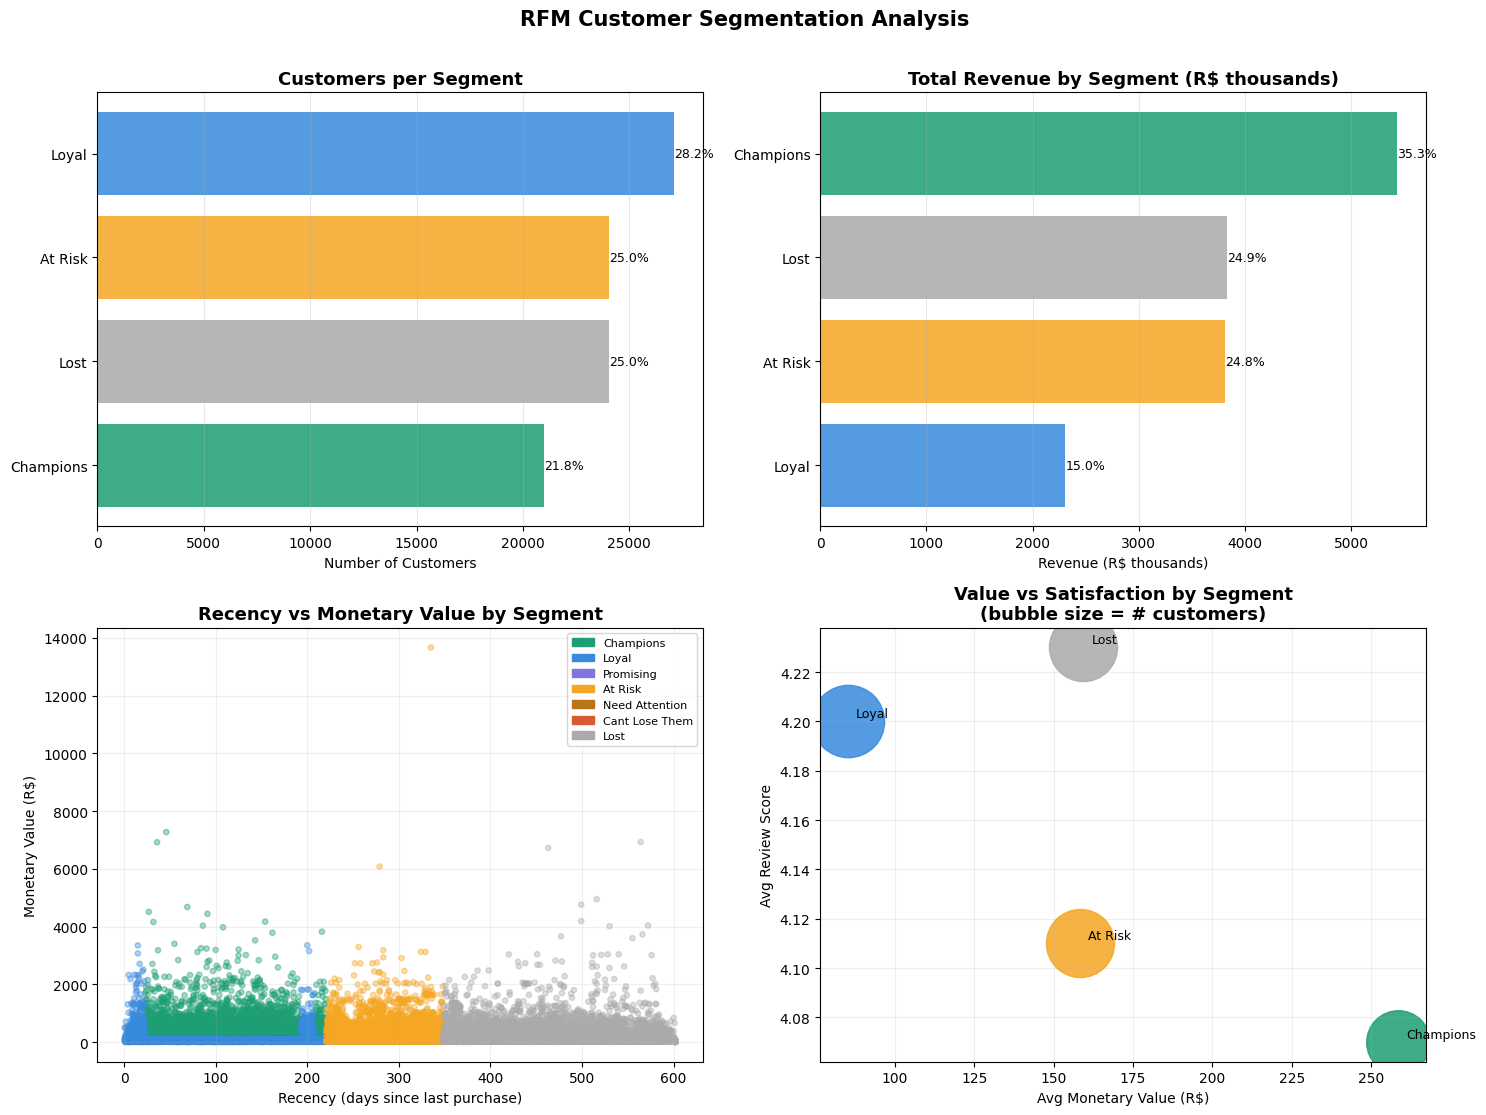

In [6]:
seg_colors = {
    'Champions'     : '#1D9E75',
    'Loyal'         : '#378ADD',
    'Promising'     : '#7F77DD',
    'At Risk'       : '#F5A623',
    'Need Attention': '#BA7517',
    'Cant Lose Them': '#D85A30',
    'Lost'          : '#AAAAAA'
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Chart 1: Customer count by segment ──
seg_order = seg_summary.sort_values('customers', ascending=True)
colors_ordered = [seg_colors.get(s, '#888') for s in seg_order['segment']]
axes[0,0].barh(seg_order['segment'],
               seg_order['customers'],
               color=colors_ordered, alpha=0.85)
axes[0,0].set_title('Customers per Segment',
                    fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Number of Customers')
axes[0,0].grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(seg_order.iterrows()):
    axes[0,0].text(row['customers'] + 10, i,
                   f"{row['pct_customers']}%",
                   va='center', fontsize=9)

# ── Chart 2: Revenue by segment ──
seg_rev = seg_summary.sort_values('total_revenue', ascending=True)
colors_rev = [seg_colors.get(s,'#888') for s in seg_rev['segment']]
axes[0,1].barh(seg_rev['segment'],
               seg_rev['total_revenue']/1000,
               color=colors_rev, alpha=0.85)
axes[0,1].set_title('Total Revenue by Segment (R$ thousands)',
                    fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Revenue (R$ thousands)')
axes[0,1].grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(seg_rev.iterrows()):
    axes[0,1].text(row['total_revenue']/1000 + 1, i,
                   f"{row['pct_revenue']}%",
                   va='center', fontsize=9)

# ── Chart 3: RFM scatter — Recency vs Monetary ──
scatter_colors = [seg_colors.get(s,'#888') for s in rfm['segment']]
axes[1,0].scatter(rfm['recency_days'], rfm['monetary'],
                  c=scatter_colors, alpha=0.4, s=15)
axes[1,0].set_xlabel('Recency (days since last purchase)')
axes[1,0].set_ylabel('Monetary Value (R$)')
axes[1,0].set_title('Recency vs Monetary Value by Segment',
                    fontsize=13, fontweight='bold')
axes[1,0].grid(alpha=0.2)
legend_patches = [mpatches.Patch(color=v, label=k)
                  for k, v in seg_colors.items()]
axes[1,0].legend(handles=legend_patches,
                 fontsize=8, loc='upper right')

# ── Chart 4: Avg order value vs avg review by segment ──
for _, row in seg_summary.iterrows():
    color = seg_colors.get(row['segment'], '#888')
    size  = row['customers'] / 10
    axes[1,1].scatter(row['avg_monetary'],
                      row['avg_review_score'],
                      s=size, color=color, alpha=0.85)
    axes[1,1].annotate(row['segment'],
                       (row['avg_monetary'], row['avg_review_score']),
                       textcoords='offset points',
                       xytext=(6, 3), fontsize=9)
axes[1,1].set_xlabel('Avg Monetary Value (R$)')
axes[1,1].set_ylabel('Avg Review Score')
axes[1,1].set_title('Value vs Satisfaction by Segment\n(bubble size = # customers)',
                    fontsize=13, fontweight='bold')
axes[1,1].grid(alpha=0.2)

plt.suptitle('RFM Customer Segmentation Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../charts/13_rfm_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
!pip3 install squarify


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


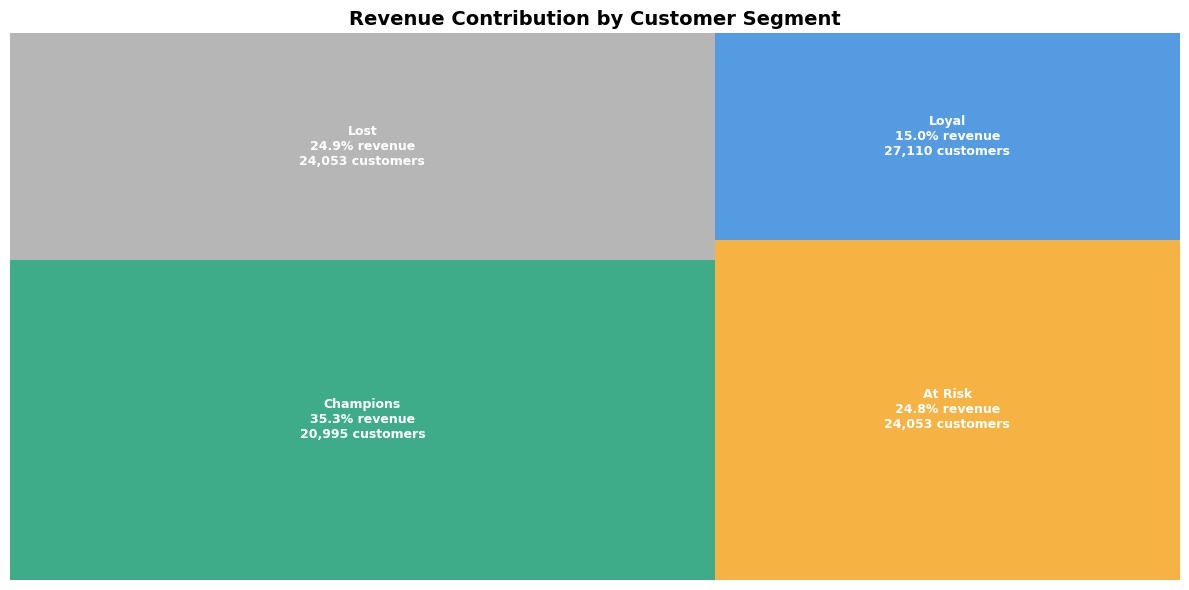

In [9]:
import squarify 

fig, ax = plt.subplots(figsize=(12, 6))
sizes  = seg_summary['total_revenue'].values
labels = [f"{row['segment']}\n{row['pct_revenue']}% revenue\n"
          f"{row['customers']:,} customers"
          for _, row in seg_summary.iterrows()]
colors = [seg_colors.get(s,'#888') for s in seg_summary['segment']]

squarify.plot(sizes=sizes, label=labels,
              color=colors, alpha=0.85, ax=ax,
              text_kwargs={'fontsize': 9,
                           'fontweight': 'bold',
                           'color': 'white'})
ax.set_title('Revenue Contribution by Customer Segment',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../charts/14_rfm_treemap.png', dpi=150)
plt.show()

In [10]:
actions = con.execute("""
    SELECT
        segment,
        COUNT(*)                        AS customers,
        ROUND(AVG(monetary), 2)         AS avg_spend,
        ROUND(AVG(recency_days), 0)     AS avg_recency
    FROM rfm
    GROUP BY segment
    ORDER BY avg_spend DESC
""").df()

# Add recommended actions
action_map = {
    'Champions'      : 'Reward with early access & loyalty perks. Ask for referrals.',
    'Loyal'          : 'Upsell higher-value categories. Offer membership program.',
    'Promising'      : 'Onboarding campaign — show breadth of catalogue.',
    'At Risk'        : 'Win-back email with personalised discount within 7 days.',
    'Need Attention' : 'Send re-engagement survey. Offer category-specific promo.',
    'Cant Lose Them' : 'Immediate personal outreach. Premium support priority.',
    'Lost'           : 'Low-cost reactivation campaign — broad discount or freebie.'
}

priority_map = {
    'Champions'      : 'Retain',
    'Loyal'          : 'Grow',
    'Promising'      : 'Convert',
    'At Risk'        : 'Recover',
    'Need Attention' : 'Re-engage',
    'Cant Lose Them' : 'Urgent',
    'Lost'           : 'Reactivate'
}

actions['action']   = actions['segment'].map(action_map)
actions['priority'] = actions['segment'].map(priority_map)

print("\nCUSTOMER SEGMENT ACTION MATRIX")
print("=" * 80)
for _, row in actions.iterrows():
    print(f"\n[{row['priority']:>10}] {row['segment']}")
    print(f"              Customers: {row['customers']:,} | "
          f"Avg spend: R${row['avg_spend']:,.0f} | "
          f"Last seen: {row['avg_recency']:.0f} days ago")
    print(f"              Action: {row['action']}")

# Save for dashboard
actions.to_csv('../data/rfm_action_matrix.csv', index=False)
rfm.to_csv('../data/rfm_scores.csv', index=False)
seg_summary.to_csv('../data/rfm_segment_summary.csv', index=False)
print("\n✓ RFM files saved")


CUSTOMER SEGMENT ACTION MATRIX

[    Retain] Champions
              Customers: 20,995 | Avg spend: R$259 | Last seen: 116 days ago
              Action: Reward with early access & loyalty perks. Ask for referrals.

[Reactivate] Lost
              Customers: 24,053 | Avg spend: R$159 | Last seen: 451 days ago
              Action: Low-cost reactivation campaign — broad discount or freebie.

[   Recover] At Risk
              Customers: 24,053 | Avg spend: R$158 | Last seen: 279 days ago
              Action: Win-back email with personalised discount within 7 days.

[      Grow] Loyal
              Customers: 27,110 | Avg spend: R$85 | Last seen: 112 days ago
              Action: Upsell higher-value categories. Offer membership program.

✓ RFM files saved



PARETO ANALYSIS — CUSTOMERS vs REVENUE
  segment  pct_customers  pct_revenue  cum_pct_customers  cum_pct_revenue
Champions           21.8         35.3               21.8             35.3
     Lost           25.0         24.9               46.8             60.2
  At Risk           25.0         24.8               71.8             85.0
    Loyal           28.2         15.0              100.0            100.0


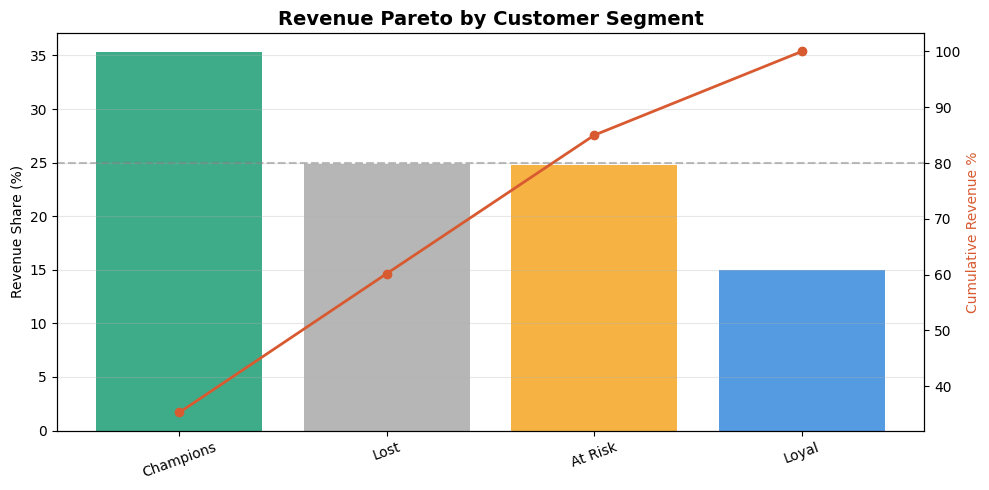

In [11]:
pareto = con.execute("""
    SELECT
        segment,
        customers,
        pct_customers,
        total_revenue,
        pct_revenue,
        SUM(pct_customers) OVER (ORDER BY total_revenue DESC) AS cum_pct_customers,
        SUM(pct_revenue)   OVER (ORDER BY total_revenue DESC) AS cum_pct_revenue
    FROM (
        SELECT
            segment,
            COUNT(*)                                         AS customers,
            ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(),1)    AS pct_customers,
            ROUND(SUM(monetary),0)                          AS total_revenue,
            ROUND(100.0*SUM(monetary)/SUM(SUM(monetary)) OVER(),1) AS pct_revenue
        FROM rfm
        GROUP BY segment
    )
    ORDER BY total_revenue DESC
""").df()

print("\nPARETO ANALYSIS — CUSTOMERS vs REVENUE")
print(pareto[['segment','pct_customers','pct_revenue',
              'cum_pct_customers','cum_pct_revenue']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(pareto))
ax.bar(pareto['segment'], pareto['pct_revenue'],
       color=[seg_colors.get(s,'#888') for s in pareto['segment']],
       alpha=0.85, label='% Revenue')
ax2 = ax.twinx()
ax2.plot(pareto['segment'], pareto['cum_pct_revenue'],
         color='#D85A30', marker='o',
         linewidth=2, label='Cumulative %')
ax2.axhline(y=80, color='gray', linestyle='--',
            alpha=0.5, label='80% threshold')
ax2.set_ylabel('Cumulative Revenue %', color='#D85A30')
ax.set_title('Revenue Pareto by Customer Segment',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue Share (%)')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../charts/15_rfm_pareto.png', dpi=150)
plt.show()